In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from xgboost import XGBClassifier, XGBRegressor
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    r2_score,
    mean_squared_error,
    mean_absolute_error
)
from scipy.stats import pearsonr, spearmanr


c:\Users\psadi\anaconda3\envs\ds6050\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# -----------------------------
# 1. Load data
# -----------------------------
try:
    df = pd.read_csv("ml_panel_noaa_x_fda_recalls_x_cost.csv")
except FileNotFoundError:
    df = pd.read_csv("ml_panel_noaa_x_fda_recalls_x_cost(1).csv")

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["state_abbr", "date"]).reset_index(drop=True)

target = "log_pathogen_cost_index"
raw_target = "pathogen_weighted_cost_index"

# Event indicator
df["event_flag"] = (df[raw_target] > 0).astype(int)

# -----------------------------
# 2. Feature engineering
# -----------------------------
# Keep non-weather time features
df["month"] = df["date"].dt.month
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

# Keep event-history features
df["event_lag1"] = df.groupby("state_abbr")["event_flag"].shift(1)
df["event_roll3"] = (
    df.groupby("state_abbr")["event_flag"]
      .transform(lambda x: x.rolling(3, min_periods=1).mean())
)

# -----------------------------
# 3. Train/test split
# -----------------------------
train_df = df[df["year"].between(2012, 2024)].copy()
test_df  = df[df["year"] >= 2025].copy()

# -----------------------------
# 4. Train-only state-derived summaries
# -----------------------------
state_baseline = train_df.groupby("state_abbr")[target].mean()
global_baseline = train_df[target].mean()

train_df["state_baseline_cost"] = train_df["state_abbr"].map(state_baseline).fillna(global_baseline)
test_df["state_baseline_cost"]  = test_df["state_abbr"].map(state_baseline).fillna(global_baseline)

state_event_rate = train_df.groupby("state_abbr")["event_flag"].mean()
global_event_rate = train_df["event_flag"].mean()

train_df["state_event_rate"] = train_df["state_abbr"].map(state_event_rate).fillna(global_event_rate)
test_df["state_event_rate"]  = test_df["state_abbr"].map(state_event_rate).fillna(global_event_rate)

# Fill lag NaNs
train_df = train_df.fillna(0)
test_df = test_df.fillna(0)

# -----------------------------
# 5. Non-weather features only
# -----------------------------
# Explicitly keep only non-weather / structural / history features
feature_cols = [
    "state_baseline_cost",
    "state_event_rate",
    "event_lag1",
    "event_roll3",
    "month",
    "month_sin",
    "month_cos"
]

X_train = train_df[feature_cols]
X_test = test_df[feature_cols]

y_train_cls = train_df["event_flag"]
y_test_cls = test_df["event_flag"]

# -----------------------------
# 6. Classifier
# -----------------------------
pos = y_train_cls.sum()
neg = len(y_train_cls) - pos
scale_pos_weight = neg / pos if pos > 0 else 1.0

clf = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    device="cuda",
    random_state=123,
    scale_pos_weight=scale_pos_weight
)

clf_param_grid = {
    "n_estimators": [100, 300, 500, 800],
    "max_depth": [2, 3, 4, 5],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.3],
    "reg_alpha": [0, 0.1, 1.0],
    "reg_lambda": [1, 5, 10]
}

tscv = TimeSeriesSplit(n_splits=6)

clf_search = RandomizedSearchCV(
    estimator=clf,
    param_distributions=clf_param_grid,
    n_iter=30,
    scoring="average_precision",
    cv=tscv,
    verbose=1,
    n_jobs=1,
    random_state=123,
    error_score="raise"
)

clf_search.fit(X_train, y_train_cls)

best_clf = clf_search.best_estimator_
train_event_prob = best_clf.predict_proba(X_train)[:, 1]
test_event_prob = best_clf.predict_proba(X_test)[:, 1]

state_struct_auc = roc_auc_score(y_test_cls, test_event_prob)
state_struct_ap = average_precision_score(y_test_cls, test_event_prob)

print("Best state/history classifier params:")
print(clf_search.best_params_)

print("\nState/history-only classifier")
print("Feature count:", len(feature_cols))
print("Features:", feature_cols)
print("Train event rate:", y_train_cls.mean())
print("Test event rate:", y_test_cls.mean())
print("Test ROC AUC:", state_struct_auc)
print("Test Average Precision:", state_struct_ap)

Fitting 6 folds for each of 30 candidates, totalling 180 fits


c:\Users\psadi\anaconda3\envs\ds6050\Lib\site-packages\xgboost\core.py:751: UserWarning: [14:47:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Best state/history classifier params:
{'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.03, 'gamma': 0.3, 'colsample_bytree': 0.8}

State/history-only classifier
Feature count: 7
Features: ['state_baseline_cost', 'state_event_rate', 'event_lag1', 'event_roll3', 'month', 'month_sin', 'month_cos']
Train event rate: 0.11561274756207902
Test event rate: 0.06717687074829932
Test ROC AUC: 0.9889052998396086
Test Average Precision: 0.8562416009736744



===== State/history-only classifier visuals =====


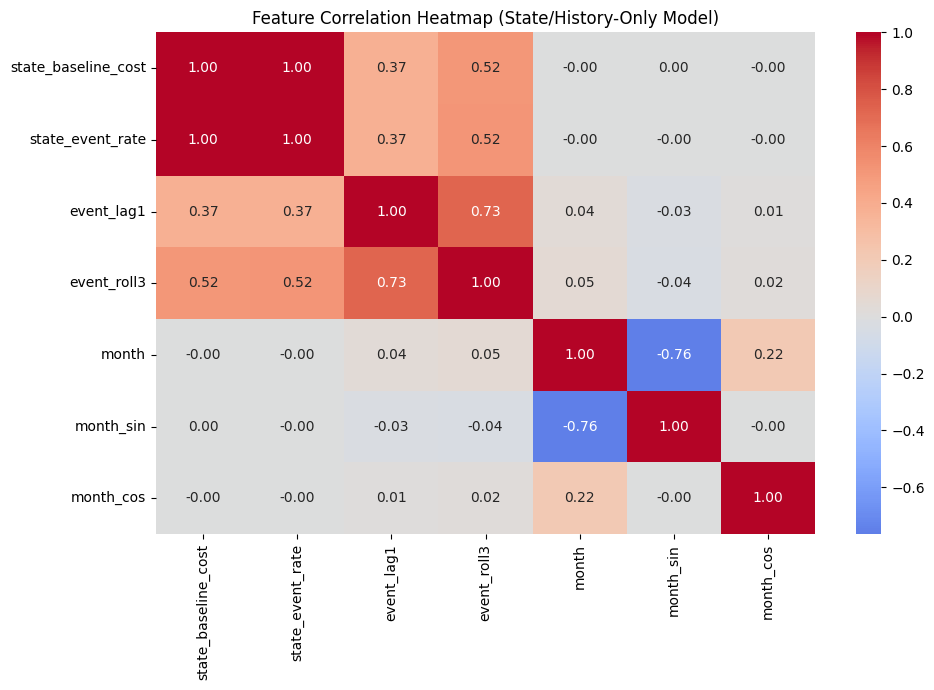

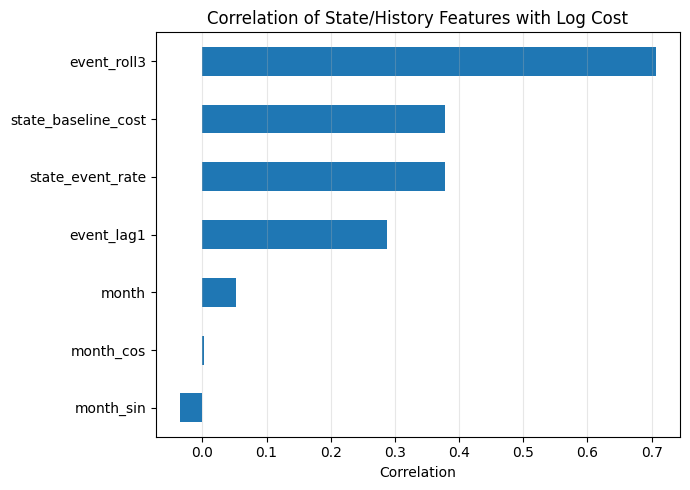

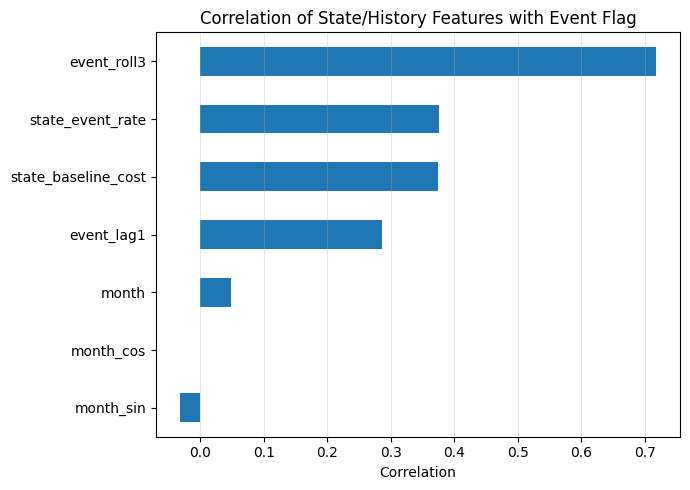

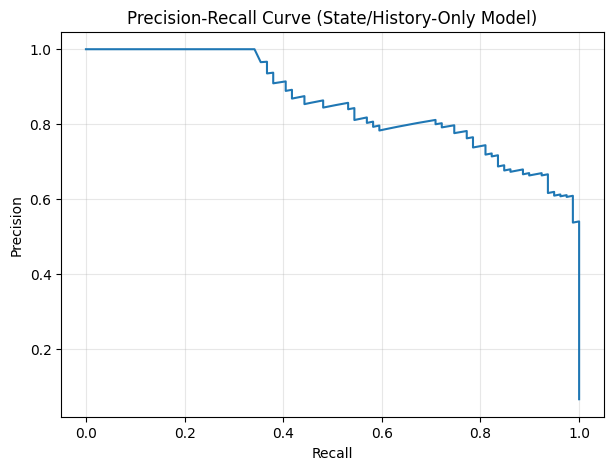

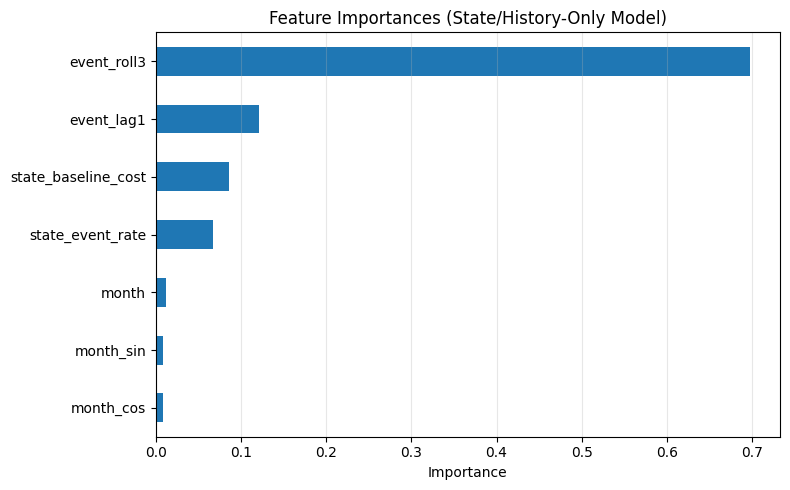


Current state/history model features:
event_roll3            0.697883
event_lag1             0.121303
state_baseline_cost    0.085605
state_event_rate       0.067647
month                  0.011455
month_sin              0.008092
month_cos              0.008015
dtype: float32

Top features used for retraining:
['event_roll3', 'event_lag1', 'state_baseline_cost', 'state_event_rate', 'month', 'month_sin', 'month_cos']

===== Refit classifier performance =====
Refit model ROC AUC: 0.9898284158175923
Refit model Average Precision: 0.8630775921022873

===== Comparison =====
Original state/history-only AUC: 0.9889052998396086
Refit model AUC: 0.9898284158175923
Original state/history-only AP: 0.8562416009736744
Refit model AP: 0.8630775921022873

=== Refit Classification Report (threshold=0.5) ===
              precision    recall  f1-score   support

           0       1.00      0.93      0.96      1097
           1       0.51      1.00      0.68        79

    accuracy                    

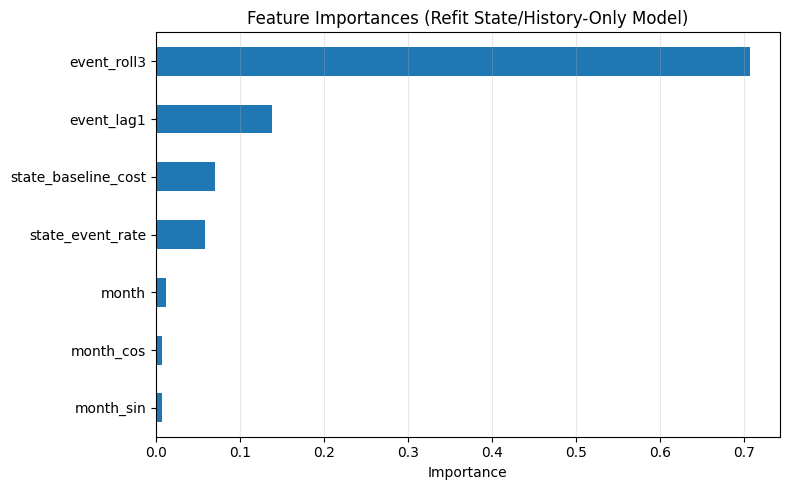

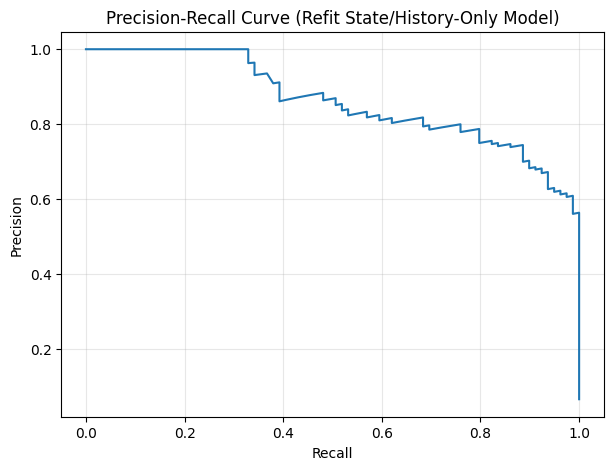

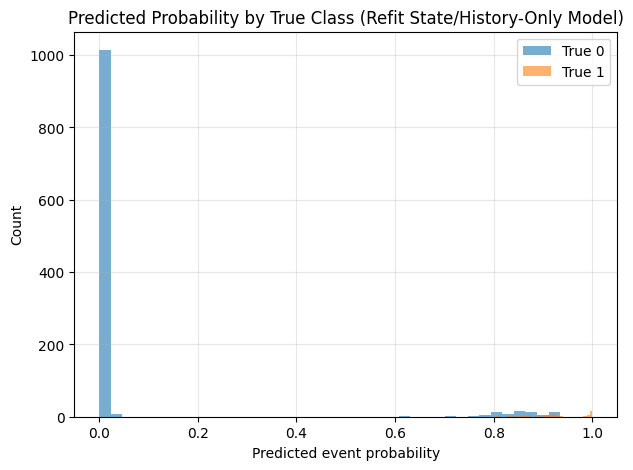

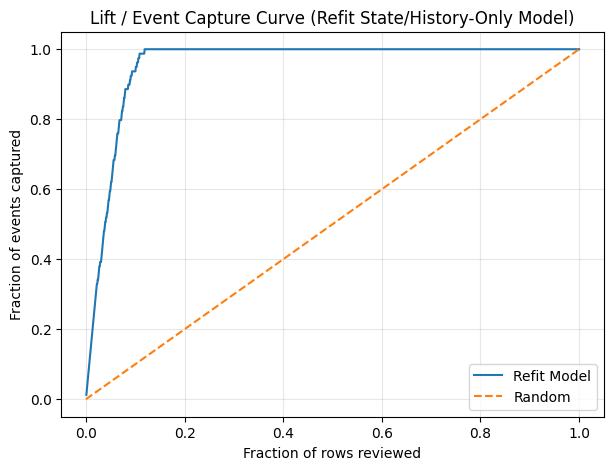

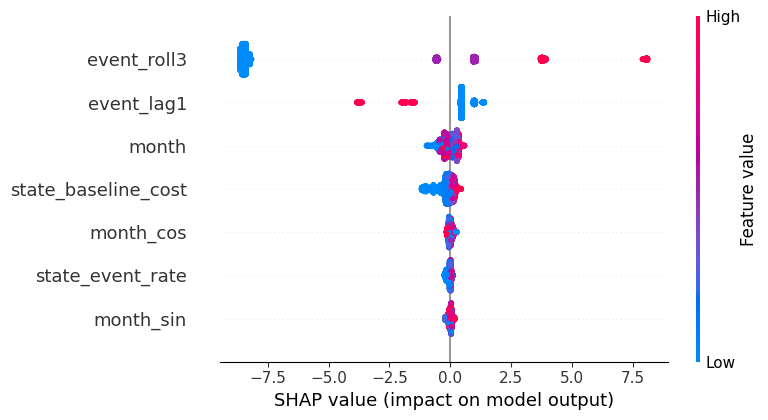

In [4]:
# -----------------------------
# State/history-only classifier visuals + correlation review
# -----------------------------
print("\n===== State/history-only classifier visuals =====")

# 1. Correlation heatmap across current predictors
plt.figure(figsize=(10, 7))
corr_statehist = train_df[feature_cols].corr()
sns.heatmap(corr_statehist, cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Feature Correlation Heatmap (State/History-Only Model)")
plt.tight_layout()
plt.show()

# 2. Correlation with target and event flag
corr_with_cost = train_df[feature_cols + [target]].corr()[target].sort_values()
corr_with_event = train_df[feature_cols + ["event_flag"]].corr()["event_flag"].sort_values()

plt.figure(figsize=(7, 5))
corr_with_cost.drop(target).plot(kind="barh")
plt.title("Correlation of State/History Features with Log Cost")
plt.xlabel("Correlation")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
corr_with_event.drop("event_flag").plot(kind="barh")
plt.title("Correlation of State/History Features with Event Flag")
plt.xlabel("Correlation")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Precision-recall curve for current state/history model
precision_statehist, recall_statehist, thresholds_statehist = precision_recall_curve(
    y_test_cls, test_event_prob
)

plt.figure(figsize=(7, 5))
plt.plot(recall_statehist, precision_statehist)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (State/History-Only Model)")
plt.grid(True, alpha=0.3)
plt.show()

# 4. Current-model feature importance
importances_statehist = pd.Series(best_clf.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importances_statehist.sort_values().plot(kind="barh")
plt.title("Feature Importances (State/History-Only Model)")
plt.xlabel("Importance")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print("\nCurrent state/history model features:")
print(importances_statehist)

# -----------------------------
# Select top features and refit
# -----------------------------
# Model only has 7 features, so "top 10" becomes all available features
top_features = importances_statehist.head(min(10, len(importances_statehist))).index.tolist()

print("\nTop features used for retraining:")
print(top_features)

X_train_top = X_train[top_features]
X_test_top = X_test[top_features]

clf_top = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    device="cuda",
    random_state=123,
    scale_pos_weight=scale_pos_weight,
    **clf_search.best_params_
)

clf_top.fit(X_train_top, y_train_cls)

train_event_prob_top = clf_top.predict_proba(X_train_top)[:, 1]
test_event_prob_top = clf_top.predict_proba(X_test_top)[:, 1]

top_auc = roc_auc_score(y_test_cls, test_event_prob_top)
top_ap = average_precision_score(y_test_cls, test_event_prob_top)

print("\n===== Refit classifier performance =====")
print("Refit model ROC AUC:", top_auc)
print("Refit model Average Precision:", top_ap)

print("\n===== Comparison =====")
print("Original state/history-only AUC:", state_struct_auc)
print("Refit model AUC:", top_auc)
print("Original state/history-only AP:", state_struct_ap)
print("Refit model AP:", top_ap)

# Threshold metrics on refit model
for thr in [0.5, 0.7, 0.85]:
    y_pred_thr = (test_event_prob_top >= thr).astype(int)
    print(f"\n=== Refit Classification Report (threshold={thr}) ===")
    print(classification_report(y_test_cls, y_pred_thr))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test_cls, y_pred_thr))

precision_top, recall_top, thresholds_top = precision_recall_curve(y_test_cls, test_event_prob_top)
f1_scores = 2 * (precision_top[:-1] * recall_top[:-1]) / (precision_top[:-1] + recall_top[:-1] + 1e-8)
best_idx = np.argmax(f1_scores)
best_thr_top = thresholds_top[best_idx]

print("\nBest threshold by F1:", best_thr_top)
print("Precision at best F1:", precision_top[best_idx])
print("Recall at best F1:", recall_top[best_idx])
print("F1 at best threshold:", f1_scores[best_idx])

# -----------------------------
# Refit-model visuals
# -----------------------------
importances_top = pd.Series(clf_top.feature_importances_, index=top_features).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importances_top.plot(kind="barh")
plt.title("Feature Importances (Refit State/History-Only Model)")
plt.xlabel("Importance")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(recall_top, precision_top)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Refit State/History-Only Model)")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7, 5))
plt.hist(test_event_prob_top[y_test_cls == 0], bins=40, alpha=0.6, label="True 0")
plt.hist(test_event_prob_top[y_test_cls == 1], bins=40, alpha=0.6, label="True 1")
plt.xlabel("Predicted event probability")
plt.ylabel("Count")
plt.title("Predicted Probability by True Class (Refit State/History-Only Model)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

lift_df = test_df.copy()
lift_df["prob_event_top"] = test_event_prob_top
lift_df = lift_df.sort_values("prob_event_top", ascending=False).reset_index(drop=True)
lift_df["cum_events"] = lift_df["event_flag"].cumsum()
total_events = lift_df["event_flag"].sum()
lift_df["cum_event_capture"] = lift_df["cum_events"] / total_events
lift_df["pct_rows_seen"] = (np.arange(len(lift_df)) + 1) / len(lift_df)

plt.figure(figsize=(7, 5))
plt.plot(lift_df["pct_rows_seen"], lift_df["cum_event_capture"], label="Refit Model")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.xlabel("Fraction of rows reviewed")
plt.ylabel("Fraction of events captured")
plt.title("Lift / Event Capture Curve (Refit State/History-Only Model)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# SHAP summary for refit model
explainer = shap.TreeExplainer(clf_top)
shap_values = explainer.shap_values(X_train_top)
shap.summary_plot(shap_values, X_train_top, feature_names=top_features)

Fitting 6 folds for each of 30 candidates, totalling 180 fits

===== 2nd Stage: Severity on Event Rows Only (State/History Features) =====
Best regressor params:
{'subsample': 1.0, 'reg_lambda': 5, 'reg_alpha': 0, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 1.0}

Event-only baseline comparison
Mean predictor R2: -0.004390227201539254
Zero predictor R2: -20.358556016283973
Event-only model R2: -0.021778084780671225

Event-only metrics
RMSE: 3.049674006243161
MAE: 2.726985719565015
R2: -0.021778084780671225

===== Additional Severity Diagnostics =====
Pearson correlation: 0.07752725448843492
Spearman correlation: 0.10628862207441363
Residual mean: 0.2337780034140397
Residual std: 3.06013007048955
Prediction std: 0.679194
Actual std: 3.016998722357807
Train event rows: 1150
Test event rows: 79


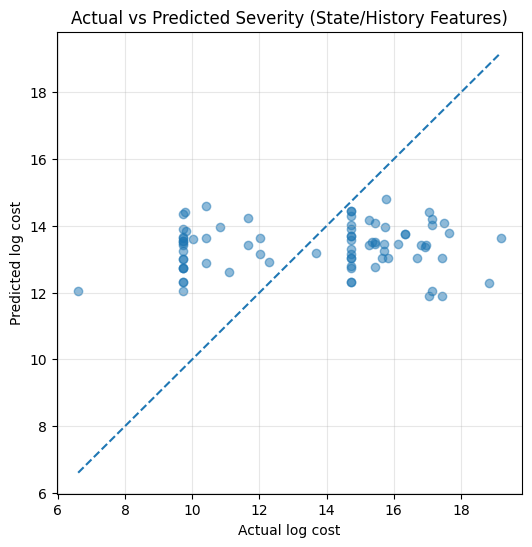

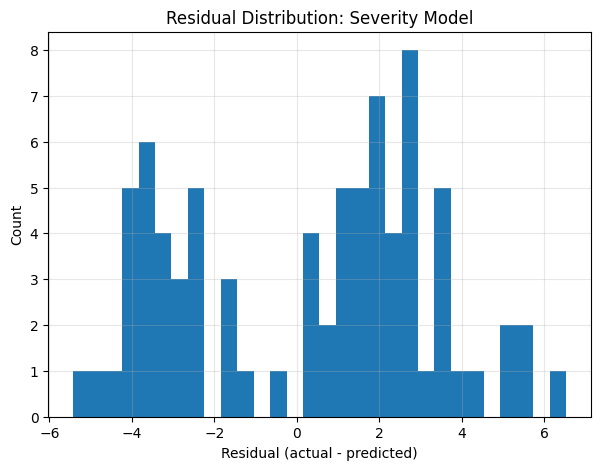

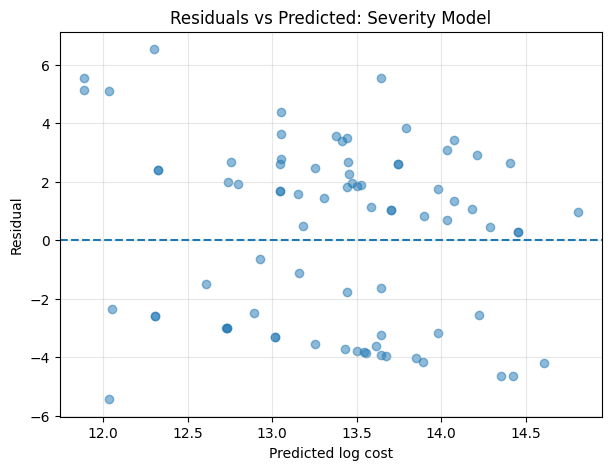

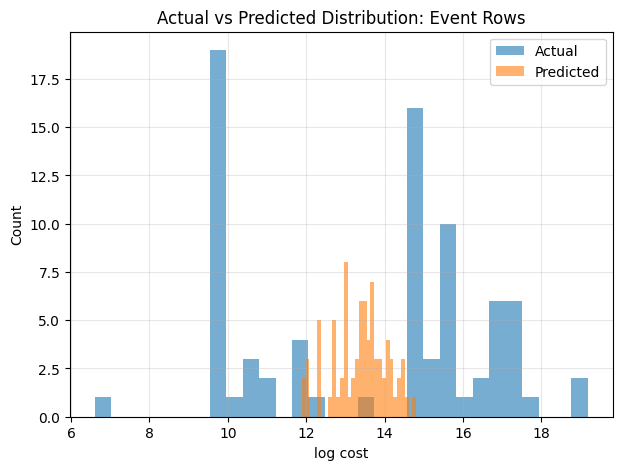

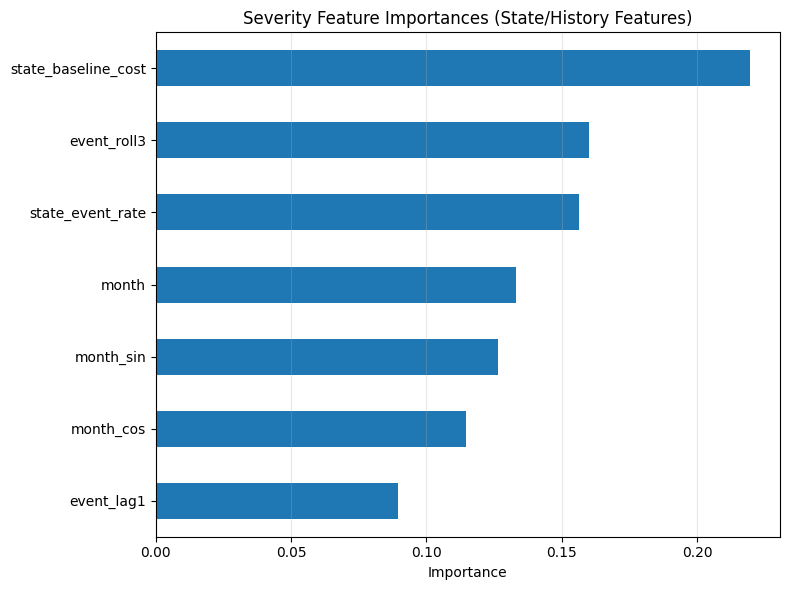


Top severity features:
state_baseline_cost    0.219657
event_roll3            0.160243
state_event_rate       0.156542
month                  0.133153
month_sin              0.126340
month_cos              0.114466
event_lag1             0.089599
dtype: float32

===== Final comparison =====
State/history-only classifier AUC: 0.9889052998396086
State/history-only classifier AP: 0.8562416009736744
Refit classifier AUC: 0.9898284158175923
Refit classifier AP: 0.8630775921022873
Severity R2 (state/history features): -0.021778084780671225


In [5]:
# -----------------------------
# 2nd stage: severity model on event rows only using state/history features
# -----------------------------
y_train_reg = train_df[target]
y_test_reg = test_df[target]

train_events_only = train_df[train_df["event_flag"] == 1].copy()
test_events_only = test_df[test_df["event_flag"] == 1].copy()

X_train_reg = train_events_only[top_features]
y_train_reg_events = train_events_only[target]

X_test_reg = test_events_only[top_features]
y_test_reg_events = test_events_only[target]

reg = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    device="cuda",
    random_state=123
)

reg_param_grid = {
    "n_estimators": [300, 500, 800, 1000],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "gamma": [0, 0.1, 0.3, 0.5],
    "reg_alpha": [0, 0.1, 1.0],
    "reg_lambda": [1, 5, 10]
}

tscv_reg = TimeSeriesSplit(n_splits=6)

reg_search = RandomizedSearchCV(
    estimator=reg,
    param_distributions=reg_param_grid,
    n_iter=30,
    scoring="r2",
    cv=tscv_reg,
    verbose=1,
    n_jobs=1,
    random_state=123,
    error_score="raise"
)

reg_search.fit(X_train_reg, y_train_reg_events)
best_reg = reg_search.best_estimator_

event_only_preds = best_reg.predict(X_test_reg)
event_only_preds = np.clip(event_only_preds, 0, None)

event_only_r2 = r2_score(y_test_reg_events, event_only_preds)
event_only_rmse = np.sqrt(mean_squared_error(y_test_reg_events, event_only_preds))
event_only_mae = mean_absolute_error(y_test_reg_events, event_only_preds)

event_mean_pred = np.repeat(y_train_reg_events.mean(), len(y_test_reg_events))
event_zero_pred = np.zeros(len(y_test_reg_events))

print("\n===== 2nd Stage: Severity on Event Rows Only (State/History Features) =====")
print("Best regressor params:")
print(reg_search.best_params_)

print("\nEvent-only baseline comparison")
print("Mean predictor R2:", r2_score(y_test_reg_events, event_mean_pred))
print("Zero predictor R2:", r2_score(y_test_reg_events, event_zero_pred))
print("Event-only model R2:", event_only_r2)

print("\nEvent-only metrics")
print("RMSE:", event_only_rmse)
print("MAE:", event_only_mae)
print("R2:", event_only_r2)

pearson_corr = pearsonr(y_test_reg_events, event_only_preds)[0]
spearman_corr = spearmanr(y_test_reg_events, event_only_preds)[0]
residuals = y_test_reg_events - event_only_preds

print("\n===== Additional Severity Diagnostics =====")
print("Pearson correlation:", pearson_corr)
print("Spearman correlation:", spearman_corr)
print("Residual mean:", residuals.mean())
print("Residual std:", residuals.std())
print("Prediction std:", np.std(event_only_preds))
print("Actual std:", np.std(y_test_reg_events))
print("Train event rows:", len(train_events_only))
print("Test event rows:", len(test_events_only))

plt.figure(figsize=(6, 6))
plt.scatter(y_test_reg_events, event_only_preds, alpha=0.5)
mn = min(y_test_reg_events.min(), event_only_preds.min())
mx = max(y_test_reg_events.max(), event_only_preds.max())
plt.plot([mn, mx], [mn, mx], linestyle="--")
plt.xlabel("Actual log cost")
plt.ylabel("Predicted log cost")
plt.title("Actual vs Predicted Severity (State/History Features)")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7, 5))
plt.hist(residuals, bins=30)
plt.xlabel("Residual (actual - predicted)")
plt.ylabel("Count")
plt.title("Residual Distribution: Severity Model")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7, 5))
plt.scatter(event_only_preds, residuals, alpha=0.5)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted log cost")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted: Severity Model")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7, 5))
plt.hist(y_test_reg_events, bins=30, alpha=0.6, label="Actual")
plt.hist(event_only_preds, bins=30, alpha=0.6, label="Predicted")
plt.xlabel("log cost")
plt.ylabel("Count")
plt.title("Actual vs Predicted Distribution: Event Rows")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

reg_importances = pd.Series(best_reg.feature_importances_, index=top_features).sort_values(ascending=False)
plt.figure(figsize=(8, 6))
reg_importances.sort_values().plot(kind="barh")
plt.title("Severity Feature Importances (State/History Features)")
plt.xlabel("Importance")
plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTop severity features:")
print(reg_importances)

print("\n===== Final comparison =====")
print("State/history-only classifier AUC:", state_struct_auc)
print("State/history-only classifier AP:", state_struct_ap)
print("Refit classifier AUC:", top_auc)
print("Refit classifier AP:", top_ap)
print("Severity R2 (state/history features):", event_only_r2)
